In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully")

Libraries imported successfully


In [5]:
from google.colab import files

uploaded = files.upload()

Saving Lead Scoring.csv to Lead Scoring.csv
Saving Leads Data Dictionary.xlsx to Leads Data Dictionary.xlsx


In [6]:
df = pd.read_csv("Lead Scoring.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (9240, 37)


In [7]:
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Select,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [9]:
df.isnull().sum().sort_values(ascending=False)

,0
Lead Quality,4767
Asymmetrique Profile Index,4218
Asymmetrique Activity Score,4218
Asymmetrique Activity Index,4218
Asymmetrique Profile Score,4218
Tags,3353
What matters most to you in choosing a course,2709
Lead Profile,2709
What is your current occupation,2690
Country,2461


In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
print("Converted value counts:")
print(df["Converted"].value_counts())

print("\nConversion percentage:")
print(df["Converted"].value_counts(normalize=True) * 100)

Converted value counts:
Converted
0    5679
1    3561
Name: count, dtype: int64

Conversion percentage:
Converted
0    61.461039
1    38.538961
Name: proportion, dtype: float64


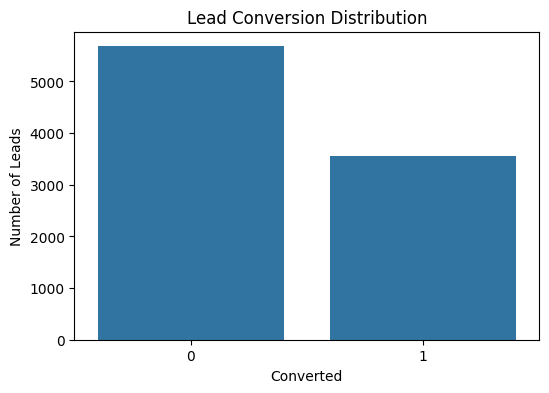

In [12]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Converted")

plt.title("Lead Conversion Distribution")
plt.xlabel("Converted")
plt.ylabel("Number of Leads")

plt.show()

In [13]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent = missing_percent.sort_values(ascending=False)

missing_percent[missing_percent > 0]

,0
Lead Quality,51.590909
Asymmetrique Profile Index,45.649351
Asymmetrique Activity Score,45.649351
Asymmetrique Activity Index,45.649351
Asymmetrique Profile Score,45.649351
Tags,36.287879
What matters most to you in choosing a course,29.318182
Lead Profile,29.318182
What is your current occupation,29.112554
Country,26.634199


In [14]:
high_missing = missing_percent[missing_percent > 40]

print("Columns with more than 40% missing values:")
print(high_missing)

Columns with more than 40% missing values:
Lead Quality                   51.590909
Asymmetrique Profile Index     45.649351
Asymmetrique Activity Score    45.649351
Asymmetrique Activity Index    45.649351
Asymmetrique Profile Score     45.649351
dtype: float64


In [15]:
for column in df.columns:
    if df[column].nunique(dropna=False) <= 1:
        print(column)

Magazine
Receive More Updates About Our Courses
Update me on Supply Chain Content
Get updates on DM Content
I agree to pay the amount through cheque


In [16]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [17]:
data = df.copy()

print("Copy created successfully")
print("Shape:", data.shape)

Copy created successfully
Shape: (9240, 37)


In [18]:
data = data.drop(
    columns=["Prospect ID", "Lead Number"],
    errors="ignore"
)

print("Identifier columns removed")
print("New shape:", data.shape)

Identifier columns removed
New shape: (9240, 35)


In [19]:
missing_ratio = data.isnull().mean()

columns_to_drop = missing_ratio[missing_ratio > 0.40].index.tolist()

print("Columns removed because of high missing values:")
print(columns_to_drop)

data = data.drop(columns=columns_to_drop)

print("\nNew dataset shape:", data.shape)

Columns removed because of high missing values:
['Lead Quality', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score']

New dataset shape: (9240, 30)


In [20]:
remaining_missing = data.isnull().sum().sort_values(ascending=False)

remaining_missing[remaining_missing > 0]

,0
Tags,3353
What matters most to you in choosing a course,2709
Lead Profile,2709
What is your current occupation,2690
Country,2461
How did you hear about X Education,2207
Specialization,1438
City,1420
Page Views Per Visit,137
TotalVisits,137


In [21]:
for column in data.select_dtypes(include="object").columns:
    count = (data[column] == "Select").sum()

    if count > 0:
        print(column, ":", count)

Specialization : 1942
How did you hear about X Education : 5043
Lead Profile : 4146
City : 2249


In [22]:
# Treat "Select" as a missing value
data = data.replace("Select", np.nan)

print("Select values have been converted to missing values.")

Select values have been converted to missing values.


In [23]:
missing_after_select = data.isnull().sum().sort_values(ascending=False)

missing_after_select[missing_after_select > 0]

,0
How did you hear about X Education,7250
Lead Profile,6855
City,3669
Specialization,3380
Tags,3353
What matters most to you in choosing a course,2709
What is your current occupation,2690
Country,2461
Page Views Per Visit,137
TotalVisits,137


In [24]:
# Separate numerical and categorical columns
numeric_columns = data.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = data.select_dtypes(include=["object"]).columns

# Fill numerical missing values with median
for column in numeric_columns:
    data[column] = data[column].fillna(data[column].median())

# Fill categorical missing values with "Unknown"
for column in categorical_columns:
    data[column] = data[column].fillna("Unknown")

print("Missing values have been handled.")

Missing values have been handled.


In [25]:
print("Total missing values:", data.isnull().sum().sum())

Total missing values: 0


In [26]:
print("Final shape:", data.shape)
data.head()

Final shape: (9240, 30)


,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,Unknown,Unknown,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,No,No,Unknown,Unknown,No,No,Modified
1,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Unknown,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,No,No,Unknown,Unknown,No,No,Email Opened
2,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Unknown,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,No,No,Potential Lead,Mumbai,No,Yes,Email Opened
3,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,No,No,Unknown,Mumbai,No,No,Modified
4,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Unknown,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,No,No,Unknown,Mumbai,No,No,Modified


In [27]:
print("Conversion counts:")
print(data["Converted"].value_counts())

print("\nConversion percentage:")
print((data["Converted"].value_counts(normalize=True) * 100).round(2))

Conversion counts:
Converted
0    5679
1    3561
Name: count, dtype: int64

Conversion percentage:
Converted
0    61.46
1    38.54
Name: proportion, dtype: float64


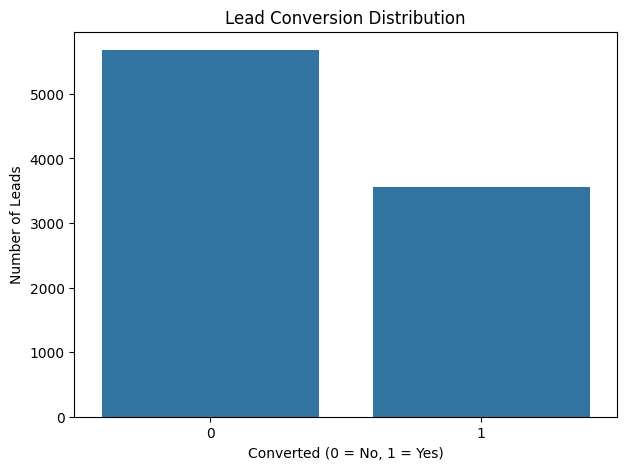

In [28]:
plt.figure(figsize=(7, 5))

sns.countplot(data=data, x="Converted")

plt.title("Lead Conversion Distribution")
plt.xlabel("Converted (0 = No, 1 = Yes)")
plt.ylabel("Number of Leads")

plt.show()

In [29]:
lead_source_conversion = (
    data.groupby("Lead Source")["Converted"]
    .mean()
    .sort_values(ascending=False) * 100
)

print(lead_source_conversion.round(2))

Lead Source
Live Chat            100.00
NC_EDM               100.00
WeLearn              100.00
Welingak Website      98.59
Reference             91.76
Unknown               80.56
Click2call            75.00
Social Media          50.00
Google                39.99
Organic Search        37.78
Direct Traffic        32.17
Olark Chat            25.53
Referral Sites        24.80
Facebook              23.64
bing                  16.67
Press_Release          0.00
Pay per Click Ads      0.00
blog                   0.00
google                 0.00
testone                0.00
welearnblog_Home       0.00
youtubechannel         0.00
Name: Converted, dtype: float64


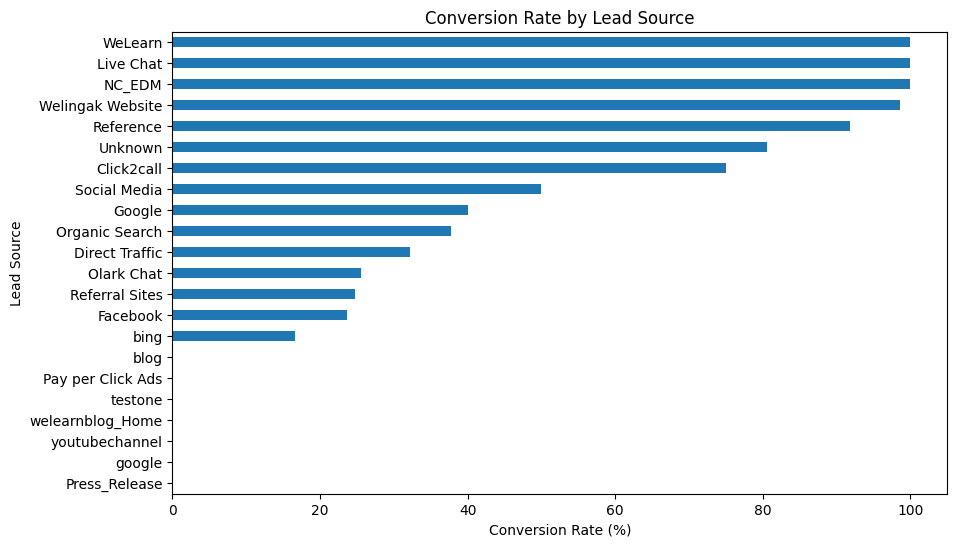

In [30]:
plt.figure(figsize=(10, 6))

lead_source_conversion.sort_values().plot(kind="barh")

plt.title("Conversion Rate by Lead Source")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Lead Source")

plt.show()

In [31]:
time_conversion = (
    data.groupby("Converted")["Total Time Spent on Website"]
    .mean()
)

print(time_conversion)

Converted
0    330.404473
1    738.546757
Name: Total Time Spent on Website, dtype: float64


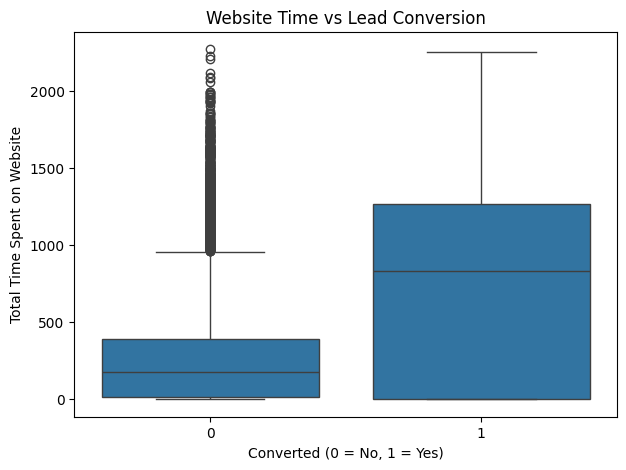

In [32]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=data,
    x="Converted",
    y="Total Time Spent on Website"
)

plt.title("Website Time vs Lead Conversion")
plt.xlabel("Converted (0 = No, 1 = Yes)")
plt.ylabel("Total Time Spent on Website")

plt.show()

In [33]:
source_analysis = data.groupby("Lead Source").agg(
    total_leads=("Converted", "count"),
    converted_leads=("Converted", "sum"),
    conversion_rate=("Converted", "mean")
)

source_analysis["conversion_rate"] = (
    source_analysis["conversion_rate"] * 100
).round(2)

source_analysis = source_analysis.sort_values(
    "total_leads",
    ascending=False
)

source_analysis

,total_leads,converted_leads,conversion_rate
Lead Source,,,
Google,2868,1147,39.99
Direct Traffic,2543,818,32.17
Olark Chat,1755,448,25.53
Organic Search,1154,436,37.78
Reference,534,490,91.76
Welingak Website,142,140,98.59
Referral Sites,125,31,24.80
Facebook,55,13,23.64
Unknown,36,29,80.56


In [34]:
reliable_sources = source_analysis[
    source_analysis["total_leads"] >= 50
].sort_values(
    "conversion_rate",
    ascending=False
)

reliable_sources

,total_leads,converted_leads,conversion_rate
Lead Source,,,
Welingak Website,142,140,98.59
Reference,534,490,91.76
Google,2868,1147,39.99
Organic Search,1154,436,37.78
Direct Traffic,2543,818,32.17
Olark Chat,1755,448,25.53
Referral Sites,125,31,24.80
Facebook,55,13,23.64


In [35]:
visit_conversion = data.groupby("Converted")["TotalVisits"].mean()

print(visit_conversion)

Converted
0    3.327522
1    3.615838
Name: TotalVisits, dtype: float64


In [36]:
page_view_conversion = data.groupby("Converted")["Page Views Per Visit"].mean()

print(page_view_conversion)

Converted
0    2.366052
1    2.343707
Name: Page Views Per Visit, dtype: float64


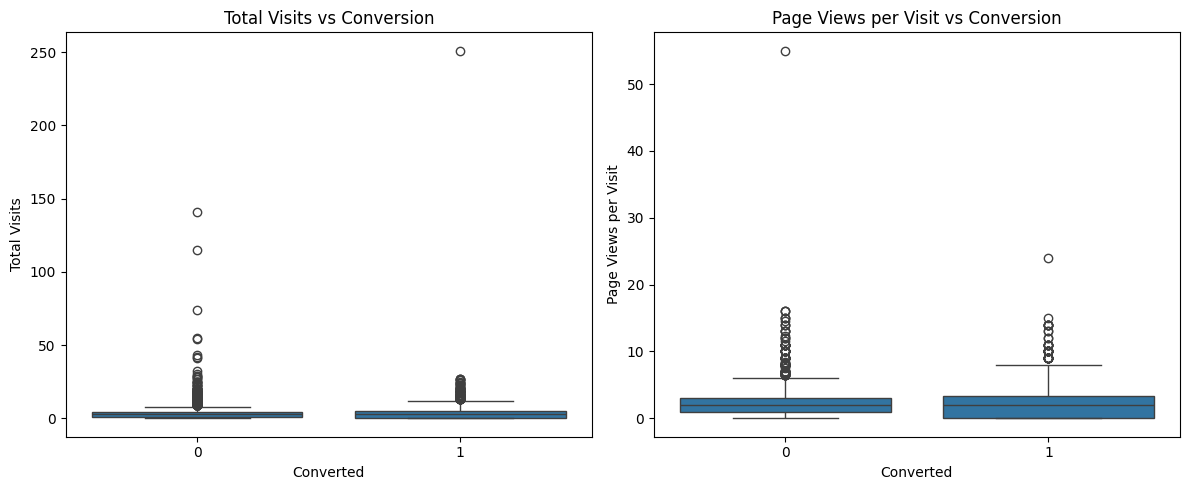

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=data,
    x="Converted",
    y="TotalVisits",
    ax=axes[0]
)

axes[0].set_title("Total Visits vs Conversion")
axes[0].set_xlabel("Converted")
axes[0].set_ylabel("Total Visits")

sns.boxplot(
    data=data,
    x="Converted",
    y="Page Views Per Visit",
    ax=axes[1]
)

axes[1].set_title("Page Views per Visit vs Conversion")
axes[1].set_xlabel("Converted")
axes[1].set_ylabel("Page Views per Visit")

plt.tight_layout()
plt.show()

In [38]:
numeric_features = [
    "TotalVisits",
    "Total Time Spent on Website",
    "Page Views Per Visit"
]

comparison = data.groupby("Converted")[numeric_features].mean().T

comparison.columns = ["Not Converted", "Converted"]

print(comparison.round(2))

                             Not Converted  Converted
TotalVisits                           3.33       3.62
Total Time Spent on Website         330.40     738.55
Page Views Per Visit                  2.37       2.34


In [39]:
correlation = data[numeric_features + ["Converted"]].corr()["Converted"]

print(correlation.sort_values(ascending=False))

Converted                      1.000000
Total Time Spent on Website    0.362483
TotalVisits                    0.029119
Page Views Per Visit          -0.005068
Name: Converted, dtype: float64


In [40]:
categorical_features = [
    "Lead Origin",
    "Lead Source",
    "Last Activity",
    "What is your current occupation",
    "Lead Profile"
]

for column in categorical_features:
    print("\n" + "=" * 60)
    print(column)
    print(data.groupby(column)["Converted"].mean().sort_values(ascending=False).head(10))


Lead Origin
Lead Origin
Quick Add Form             1.000000
Lead Add Form              0.924791
Landing Page Submission    0.361850
API                        0.311453
Lead Import                0.236364
Name: Converted, dtype: float64

Lead Source
Lead Source
Live Chat           1.000000
NC_EDM              1.000000
WeLearn             1.000000
Welingak Website    0.985915
Reference           0.917603
Unknown             0.805556
Click2call          0.750000
Social Media        0.500000
Google              0.399930
Organic Search      0.377816
Name: Converted, dtype: float64

Last Activity
Last Activity
Approached upfront          1.000000
Email Marked Spam           1.000000
Resubscribed to emails      1.000000
Email Received              1.000000
Unknown                     0.786408
Had a Phone Conversation    0.733333
SMS Sent                    0.629144
Email Opened                0.364562
Unreachable                 0.333333
Email Link Clicked          0.273408
Name: Converted, 

In [41]:
target_ratio = data["Converted"].value_counts(normalize=True)

print("Class distribution:")
print(target_ratio)

print("\nDifference between classes:")
print(abs(target_ratio[0] - target_ratio[1]))

Class distribution:
Converted
0    0.61461
1    0.38539
Name: proportion, dtype: float64

Difference between classes:
0.2292207792207792


In [42]:
X = data.drop("Converted", axis=1)
y = data["Converted"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (9240, 29)
Target shape: (9240,)


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7392, 29)
Testing data: (1848, 29)


In [44]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']

Categorical features:
['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Tags', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'Lead Profile', 'City', 'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview', 'Last Notable Activity']


In [45]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [46]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Logistic Regression pipeline created.")

Logistic Regression pipeline created.


In [47]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [48]:
y_pred = logistic_model.predict(X_test)
y_probability = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("First 10 probabilities:")
print(y_probability[:10])

Predictions generated successfully.
First 10 probabilities:
[0.1935414  0.97107289 0.0399149  0.00365969 0.00199309 0.01390994
 0.31671293 0.21307093 0.10065821 0.02372968]


In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_probability), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9324
Precision: 0.9235
Recall   : 0.8989
F1 Score : 0.911
ROC-AUC  : 0.9759

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.95      0.95      1136
           1       0.92      0.90      0.91       712

    accuracy                           0.93      1848
   macro avg       0.93      0.93      0.93      1848
weighted avg       0.93      0.93      0.93      1848



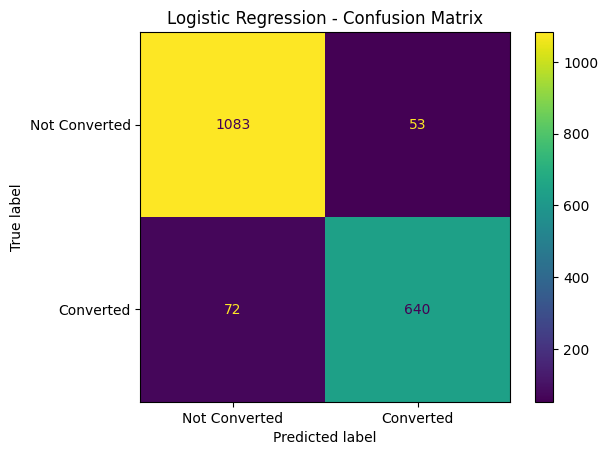

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Converted", "Converted"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

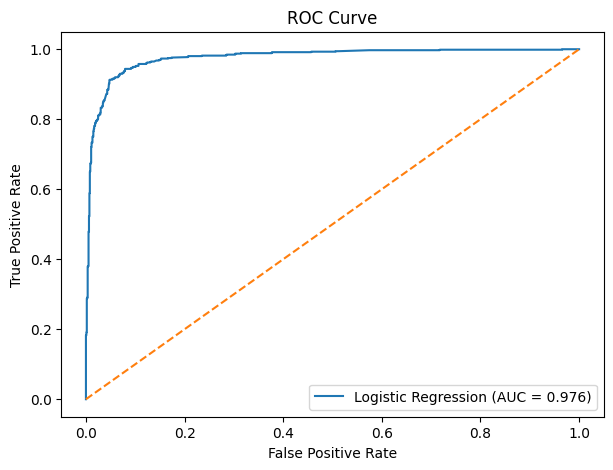

In [51]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [52]:
lead_scores = (y_probability * 100).round(2)

score_df = pd.DataFrame({
    "Actual_Converted": y_test.values,
    "Conversion_Probability": y_probability.round(4),
    "Lead_Score": lead_scores
})

score_df.head(10)

,Actual_Converted,Conversion_Probability,Lead_Score
0,1,0.1935,19.35
1,1,0.9711,97.11
2,0,0.0399,3.99
3,0,0.0037,0.37
4,0,0.0020,0.20
5,0,0.0139,1.39
6,0,0.3167,31.67
7,0,0.2131,21.31
8,0,0.1007,10.07
9,0,0.0237,2.37


In [53]:
def assign_priority(score):

    if score >= 70:
        return "High"

    elif score >= 40:
        return "Medium"

    else:
        return "Low"


score_df["Priority"] = score_df["Lead_Score"].apply(assign_priority)

score_df.head(10)

,Actual_Converted,Conversion_Probability,Lead_Score,Priority
0,1,0.1935,19.35,Low
1,1,0.9711,97.11,High
2,0,0.0399,3.99,Low
3,0,0.0037,0.37,Low
4,0,0.0020,0.20,Low
5,0,0.0139,1.39,Low
6,0,0.3167,31.67,Low
7,0,0.2131,21.31,Low
8,0,0.1007,10.07,Low
9,0,0.0237,2.37,Low


In [54]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_split=5,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created.")

Random Forest pipeline created.


In [55]:
random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [56]:
rf_pred = random_forest_model.predict(X_test)

rf_probability = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated.")

Random Forest predictions generated.


In [57]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_probability)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

Random Forest Results
---------------------
Accuracy : 0.9297
Precision: 0.9369
Recall   : 0.8764
F1 Score : 0.9057
ROC-AUC  : 0.9735


In [58]:
from xgboost import XGBClassifier

print("XGBoost imported successfully.")

XGBoost imported successfully.


In [59]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

print("XGBoost pipeline created.")

XGBoost pipeline created.


In [60]:
xgb_model.fit(X_train, y_train)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [61]:
xgb_pred = xgb_model.predict(X_test)

xgb_probability = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost predictions generated.")

XGBoost predictions generated.


In [62]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_probability)

print("XGBoost Results")
print("----------------")
print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1 Score :", round(xgb_f1, 4))
print("ROC-AUC  :", round(xgb_auc, 4))

XGBoost Results
----------------
Accuracy : 0.9405
Precision: 0.9337
Recall   : 0.9101
F1 Score : 0.9218
ROC-AUC  : 0.98


In [63]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_probability),
        rf_auc,
        xgb_auc
    ]
})

model_comparison = model_comparison.round(4)

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9324,0.9235,0.8989,0.9110,0.9759
1,Random Forest,0.9297,0.9369,0.8764,0.9057,0.9735
2,XGBoost,0.9405,0.9337,0.9101,0.9218,0.9800


<Figure size 900x500 with 0 Axes>

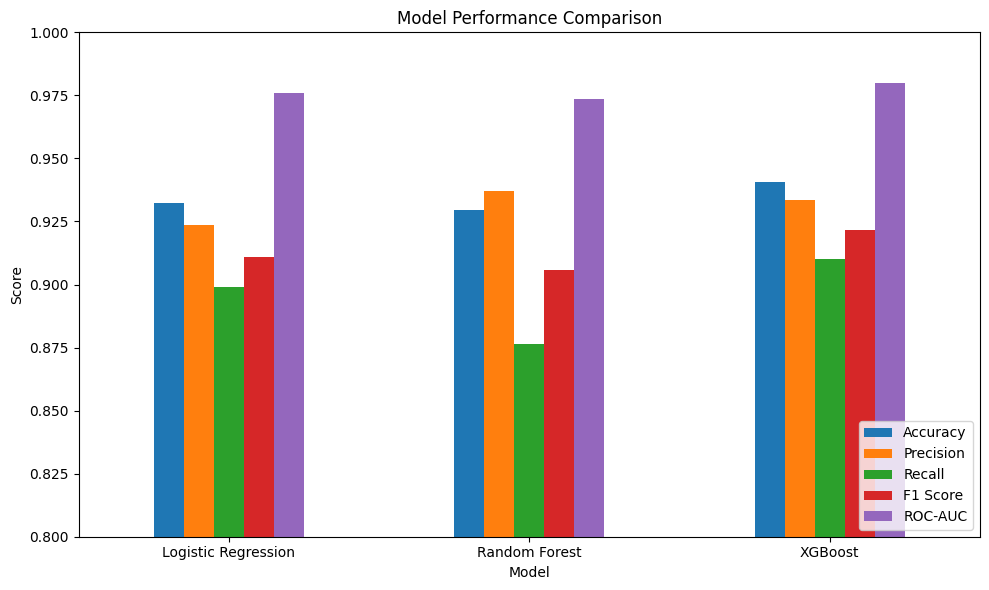

In [64]:
plt.figure(figsize=(9, 5))

model_comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(kind="bar", figsize=(10, 6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [65]:
final_model = xgb_model

print("Final model selected: XGBoost")
print("ROC-AUC:", round(xgb_auc, 4))

Final model selected: XGBoost
ROC-AUC: 0.98


In [66]:
final_probability = final_model.predict_proba(X_test)[:, 1]

lead_score = (final_probability * 100).round(2)

lead_scoring = X_test.copy()

lead_scoring["Conversion_Probability"] = final_probability.round(4)

lead_scoring["Lead_Score"] = lead_score

lead_scoring["Actual_Converted"] = y_test.values

lead_scoring.head(10)

,Lead Origin,Lead Source,Do Not Email,Do Not Call,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity,Conversion_Probability,Lead_Score,Actual_Converted
683,Landing Page Submission,Referral Sites,No,No,6.0,1505,6.0,Page Visited on Website,India,Human Resource Management,Unknown,Unknown,Unknown,No,No,No,No,No,No,No,No,Unknown,No,No,Unknown,Other Cities,No,Yes,Page Visited on Website,0.1960,19.600000,1
1931,API,Olark Chat,No,No,0.0,0,0.0,SMS Sent,Unknown,Unknown,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,No,No,Potential Lead,Unknown,No,No,Modified,0.9674,96.739998,1
6950,Landing Page Submission,Direct Traffic,No,No,2.0,310,2.0,SMS Sent,India,Marketing Management,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,No,No,Unknown,Other Metro Cities,No,Yes,SMS Sent,0.0388,3.880000,0
2996,Landing Page Submission,Direct Traffic,No,No,3.0,307,3.0,Email Opened,India,Finance Management,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,switched off,No,No,Unknown,Mumbai,No,Yes,Email Opened,0.0055,0.550000,0
3902,Landing Page Submission,Direct Traffic,No,No,4.0,234,4.0,Email Link Clicked,India,Finance Management,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,No,No,Unknown,Thane & Outskirts,No,Yes,Email Link Clicked,0.0101,1.010000,0
6828,Landing Page Submission,Direct Traffic,No,No,11.0,420,5.5,Email Opened,India,Business Administration,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,invalid number,No,No,Unknown,Other Cities,No,Yes,Email Opened,0.0109,1.090000,0
4906,API,Google,No,No,2.0,102,2.0,SMS Sent,India,Unknown,Unknown,Unknown,Unknown,No,No,No,No,No,No,No,No,Unknown,No,No,Unknown,Unknown,No,No,SMS Sent,0.3664,36.639999,0
5796,API,Olark Chat,No,No,0.0,0,0.0,Olark Chat Conversation,Unknown,Unknown,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Unknown,No,No,Unknown,Unknown,No,No,Olark Chat Conversation,0.1719,17.190001,0
6388,API,Olark Chat,No,No,0.0,0,0.0,Email Opened,Unknown,Unknown,Unknown,Unknown,Unknown,No,No,No,No,No,No,No,No,Unknown,No,No,Unknown,Unknown,No,No,Email Opened,0.0619,6.190000,0
3636,API,bing,No,No,1.0,458,1.0,Converted to Lead,India,Unknown,Unknown,Unknown,Unknown,No,No,No,No,No,No,No,No,Unknown,No,No,Unknown,Unknown,No,No,Modified,0.0110,1.100000,0


In [67]:
def assign_priority(score):

    if score >= 70:
        return "High"

    elif score >= 40:
        return "Medium"

    else:
        return "Low"


lead_scoring["Priority"] = lead_scoring["Lead_Score"].apply(
    assign_priority
)

lead_scoring.head(10)

,Lead Origin,Lead Source,Do Not Email,Do Not Call,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity,Conversion_Probability,Lead_Score,Actual_Converted,Priority
683,Landing Page Submission,Referral Sites,No,No,6.0,1505,6.0,Page Visited on Website,India,Human Resource Management,Unknown,Unknown,Unknown,No,No,No,No,No,No,No,No,Unknown,No,No,Unknown,Other Cities,No,Yes,Page Visited on Website,0.1960,19.600000,1,Low
1931,API,Olark Chat,No,No,0.0,0,0.0,SMS Sent,Unknown,Unknown,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,No,No,Potential Lead,Unknown,No,No,Modified,0.9674,96.739998,1,High
6950,Landing Page Submission,Direct Traffic,No,No,2.0,310,2.0,SMS Sent,India,Marketing Management,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,No,No,Unknown,Other Metro Cities,No,Yes,SMS Sent,0.0388,3.880000,0,Low
2996,Landing Page Submission,Direct Traffic,No,No,3.0,307,3.0,Email Opened,India,Finance Management,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,switched off,No,No,Unknown,Mumbai,No,Yes,Email Opened,0.0055,0.550000,0,Low
3902,Landing Page Submission,Direct Traffic,No,No,4.0,234,4.0,Email Link Clicked,India,Finance Management,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,No,No,Unknown,Thane & Outskirts,No,Yes,Email Link Clicked,0.0101,1.010000,0,Low
6828,Landing Page Submission,Direct Traffic,No,No,11.0,420,5.5,Email Opened,India,Business Administration,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,invalid number,No,No,Unknown,Other Cities,No,Yes,Email Opened,0.0109,1.090000,0,Low
4906,API,Google,No,No,2.0,102,2.0,SMS Sent,India,Unknown,Unknown,Unknown,Unknown,No,No,No,No,No,No,No,No,Unknown,No,No,Unknown,Unknown,No,No,SMS Sent,0.3664,36.639999,0,Low
5796,API,Olark Chat,No,No,0.0,0,0.0,Olark Chat Conversation,Unknown,Unknown,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Unknown,No,No,Unknown,Unknown,No,No,Olark Chat Conversation,0.1719,17.190001,0,Low
6388,API,Olark Chat,No,No,0.0,0,0.0,Email Opened,Unknown,Unknown,Unknown,Unknown,Unknown,No,No,No,No,No,No,No,No,Unknown,No,No,Unknown,Unknown,No,No,Email Opened,0.0619,6.190000,0,Low
3636,API,bing,No,No,1.0,458,1.0,Converted to Lead,India,Unknown,Unknown,Unknown,Unknown,No,No,No,No,No,No,No,No,Unknown,No,No,Unknown,Unknown,No,No,Modified,0.0110,1.100000,0,Low


In [68]:
priority_counts = lead_scoring["Priority"].value_counts()

print(priority_counts)

Priority
Low       1128
High       663
Medium      57
Name: count, dtype: int64


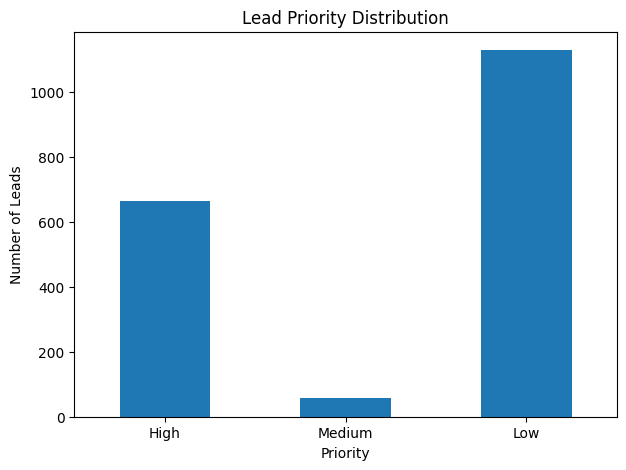

In [69]:
plt.figure(figsize=(7, 5))

priority_counts.reindex(
    ["High", "Medium", "Low"]
).plot(kind="bar")

plt.title("Lead Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Number of Leads")

plt.xticks(rotation=0)
plt.show()

In [70]:
# Get the trained XGBoost model
xgb_classifier = final_model.named_steps["model"]

# Get the preprocessing step
preprocessor_fitted = final_model.named_steps["preprocessor"]

# Get feature names after encoding
feature_names = preprocessor_fitted.get_feature_names_out()

# Get feature importance from XGBoost
importance = xgb_classifier.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
156,categorical__Tags_Will revert after reading th...,0.234154
5,categorical__Lead Origin_Lead Add Form,0.119192
138,categorical__Tags_Closed by Horizzon,0.061216
16,categorical__Lead Source_Reference,0.043088
20,categorical__Lead Source_Welingak Website,0.039029
119,categorical__What matters most to you in choos...,0.037519
146,categorical__Tags_Lost to EINS,0.034696
192,categorical__Last Notable Activity_SMS Sent,0.034438
150,categorical__Tags_Ringing,0.028244
154,categorical__Tags_Unknown,0.024767


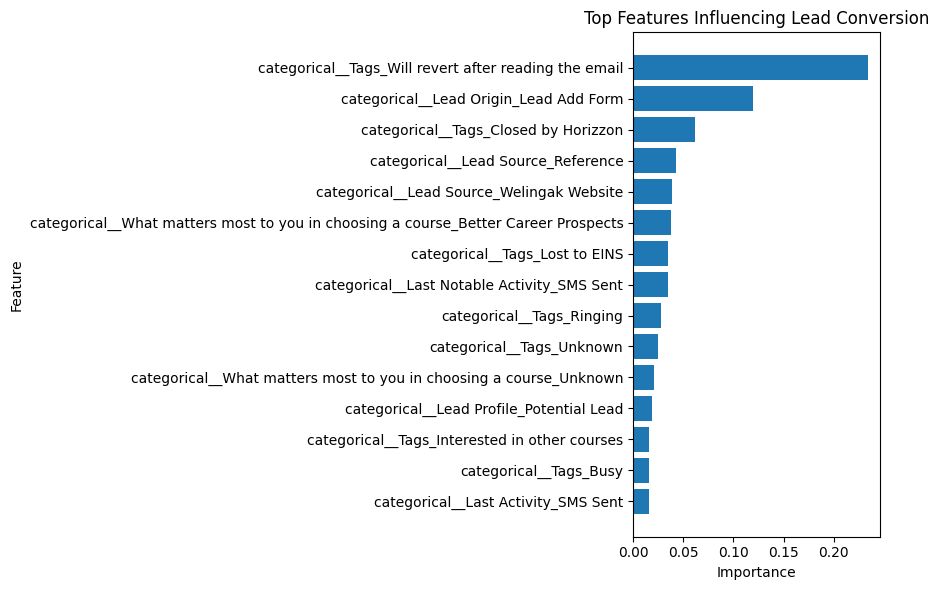

In [71]:
top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top Features Influencing Lead Conversion")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [72]:
lead_scoring.to_csv(
    "lead_scoring_results.csv",
    index=False
)

print("Lead scoring results saved successfully.")

Lead scoring results saved successfully.


In [73]:
from google.colab import files

files.download("lead_scoring_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [74]:
# Features that may contain information from later stages
leakage_features = [
    "Tags",
    "Last Activity"
]

print("Potentially leakage-prone features:")
print(leakage_features)

Potentially leakage-prone features:
['Tags', 'Last Activity']


In [75]:
safe_data = data.drop(
    columns=leakage_features,
    errors="ignore"
)

print("Original shape:", data.shape)
print("Leakage-aware shape:", safe_data.shape)

Original shape: (9240, 30)
Leakage-aware shape: (9240, 28)


In [76]:
X_safe = safe_data.drop("Converted", axis=1)
y_safe = safe_data["Converted"]

print("Safe features:", X_safe.shape)
print("Target:", y_safe.shape)

Safe features: (9240, 27)
Target: (9240,)


In [77]:
X_train_safe, X_test_safe, y_train_safe, y_test_safe = train_test_split(
    X_safe,
    y_safe,
    test_size=0.20,
    random_state=42,
    stratify=y_safe
)

print("Training data:", X_train_safe.shape)
print("Testing data:", X_test_safe.shape)

Training data: (7392, 27)
Testing data: (1848, 27)


In [78]:
safe_numeric_features = X_safe.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

safe_categorical_features = X_safe.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(safe_numeric_features)

print("\nCategorical features:")
print(safe_categorical_features)

Numerical features:
['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']

Categorical features:
['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'Lead Profile', 'City', 'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview', 'Last Notable Activity']


In [79]:
safe_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            safe_numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            safe_categorical_features
        )
    ]
)

print("Leakage-aware preprocessing pipeline created.")

Leakage-aware preprocessing pipeline created.


In [80]:
safe_xgb_model = Pipeline(
    steps=[
        ("preprocessor", safe_preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

print("Leakage-aware XGBoost model created.")

Leakage-aware XGBoost model created.


In [81]:
safe_xgb_model.fit(
    X_train_safe,
    y_train_safe
)

print("Leakage-aware XGBoost trained successfully.")

Leakage-aware XGBoost trained successfully.


In [82]:
safe_pred = safe_xgb_model.predict(X_test_safe)

safe_probability = safe_xgb_model.predict_proba(
    X_test_safe
)[:, 1]

print("Predictions generated.")

Predictions generated.


In [83]:
safe_accuracy = accuracy_score(
    y_test_safe,
    safe_pred
)

safe_precision = precision_score(
    y_test_safe,
    safe_pred
)

safe_recall = recall_score(
    y_test_safe,
    safe_pred
)

safe_f1 = f1_score(
    y_test_safe,
    safe_pred
)

safe_auc = roc_auc_score(
    y_test_safe,
    safe_probability
)

print("Leakage-Aware XGBoost Results")
print("-------------------------------")
print("Accuracy :", round(safe_accuracy, 4))
print("Precision:", round(safe_precision, 4))
print("Recall   :", round(safe_recall, 4))
print("F1 Score :", round(safe_f1, 4))
print("ROC-AUC  :", round(safe_auc, 4))

Leakage-Aware XGBoost Results
-------------------------------
Accuracy : 0.8328
Precision: 0.7985
Recall   : 0.757
F1 Score : 0.7772
ROC-AUC  : 0.901


In [84]:
final_model = xgb_model

print("Final model: XGBoost")
print("ROC-AUC:", round(xgb_auc, 4))

Final model: XGBoost
ROC-AUC: 0.98


In [85]:
final_probability = final_model.predict_proba(X_test)[:, 1]

final_scores = (final_probability * 100).round(2)

final_results = X_test.copy()

final_results["Conversion_Probability"] = final_probability.round(4)
final_results["Lead_Score"] = final_scores
final_results["Actual_Converted"] = y_test.values

final_results.head(10)

,Lead Origin,Lead Source,Do Not Email,Do Not Call,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity,Conversion_Probability,Lead_Score,Actual_Converted
683,Landing Page Submission,Referral Sites,No,No,6.0,1505,6.0,Page Visited on Website,India,Human Resource Management,Unknown,Unknown,Unknown,No,No,No,No,No,No,No,No,Unknown,No,No,Unknown,Other Cities,No,Yes,Page Visited on Website,0.1960,19.600000,1
1931,API,Olark Chat,No,No,0.0,0,0.0,SMS Sent,Unknown,Unknown,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,No,No,Potential Lead,Unknown,No,No,Modified,0.9674,96.739998,1
6950,Landing Page Submission,Direct Traffic,No,No,2.0,310,2.0,SMS Sent,India,Marketing Management,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,No,No,Unknown,Other Metro Cities,No,Yes,SMS Sent,0.0388,3.880000,0
2996,Landing Page Submission,Direct Traffic,No,No,3.0,307,3.0,Email Opened,India,Finance Management,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,switched off,No,No,Unknown,Mumbai,No,Yes,Email Opened,0.0055,0.550000,0
3902,Landing Page Submission,Direct Traffic,No,No,4.0,234,4.0,Email Link Clicked,India,Finance Management,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,No,No,Unknown,Thane & Outskirts,No,Yes,Email Link Clicked,0.0101,1.010000,0
6828,Landing Page Submission,Direct Traffic,No,No,11.0,420,5.5,Email Opened,India,Business Administration,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,invalid number,No,No,Unknown,Other Cities,No,Yes,Email Opened,0.0109,1.090000,0
4906,API,Google,No,No,2.0,102,2.0,SMS Sent,India,Unknown,Unknown,Unknown,Unknown,No,No,No,No,No,No,No,No,Unknown,No,No,Unknown,Unknown,No,No,SMS Sent,0.3664,36.639999,0
5796,API,Olark Chat,No,No,0.0,0,0.0,Olark Chat Conversation,Unknown,Unknown,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Unknown,No,No,Unknown,Unknown,No,No,Olark Chat Conversation,0.1719,17.190001,0
6388,API,Olark Chat,No,No,0.0,0,0.0,Email Opened,Unknown,Unknown,Unknown,Unknown,Unknown,No,No,No,No,No,No,No,No,Unknown,No,No,Unknown,Unknown,No,No,Email Opened,0.0619,6.190000,0
3636,API,bing,No,No,1.0,458,1.0,Converted to Lead,India,Unknown,Unknown,Unknown,Unknown,No,No,No,No,No,No,No,No,Unknown,No,No,Unknown,Unknown,No,No,Modified,0.0110,1.100000,0


In [86]:
def assign_priority(score):
    if score >= 70:
        return "High"
    elif score >= 40:
        return "Medium"
    else:
        return "Low"


final_results["Priority"] = final_results["Lead_Score"].apply(
    assign_priority
)

print(final_results["Priority"].value_counts())

Priority
Low       1128
High       663
Medium      57
Name: count, dtype: int64


In [87]:
priority_performance = (
    final_results
    .groupby("Priority")["Actual_Converted"]
    .agg(
        total_leads="count",
        converted_leads="sum",
        conversion_rate="mean"
    )
)

priority_performance["conversion_rate"] = (
    priority_performance["conversion_rate"] * 100
).round(2)

priority_performance = priority_performance.reindex(
    ["High", "Medium", "Low"]
)

priority_performance

,total_leads,converted_leads,conversion_rate
Priority,,,
High,663,627,94.57
Medium,57,32,56.14
Low,1128,53,4.70


In [88]:
# Get the trained XGBoost model
final_xgb = final_model.named_steps["model"]

# Get the fitted preprocessing step
final_preprocessor = final_model.named_steps["preprocessor"]

# Get feature names after preprocessing
final_feature_names = final_preprocessor.get_feature_names_out()

# Get feature importance
final_importance = final_xgb.feature_importances_

feature_importance_final = pd.DataFrame({
    "Feature": final_feature_names,
    "Importance": final_importance
})

feature_importance_final = feature_importance_final.sort_values(
    "Importance",
    ascending=False
)

feature_importance_final.head(15)

,Feature,Importance
156,categorical__Tags_Will revert after reading th...,0.234154
5,categorical__Lead Origin_Lead Add Form,0.119192
138,categorical__Tags_Closed by Horizzon,0.061216
16,categorical__Lead Source_Reference,0.043088
20,categorical__Lead Source_Welingak Website,0.039029
119,categorical__What matters most to you in choos...,0.037519
146,categorical__Tags_Lost to EINS,0.034696
192,categorical__Last Notable Activity_SMS Sent,0.034438
150,categorical__Tags_Ringing,0.028244
154,categorical__Tags_Unknown,0.024767


In [89]:
def get_original_feature(feature_name):
    if "__" in feature_name:
        feature_name = feature_name.split("__", 1)[1]

    for column in data.columns:
        if feature_name == column or feature_name.startswith(column + "_"):
            return column

    return feature_name


feature_importance_final["Original_Feature"] = (
    feature_importance_final["Feature"]
    .apply(get_original_feature)
)

grouped_importance = (
    feature_importance_final
    .groupby("Original_Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
)

print(grouped_importance.head(15).round(4))

Original_Feature
Tags                                             0.4563
Lead Origin                                      0.1325
Lead Source                                      0.0971
What matters most to you in choosing a course    0.0585
Last Notable Activity                            0.0550
Last Activity                                    0.0444
Specialization                                   0.0352
Lead Profile                                     0.0279
What is your current occupation                  0.0208
How did you hear about X Education               0.0162
City                                             0.0143
Total Time Spent on Website                      0.0122
Country                                          0.0096
Do Not Email                                     0.0089
A free copy of Mastering The Interview           0.0046
Name: Importance, dtype: float32


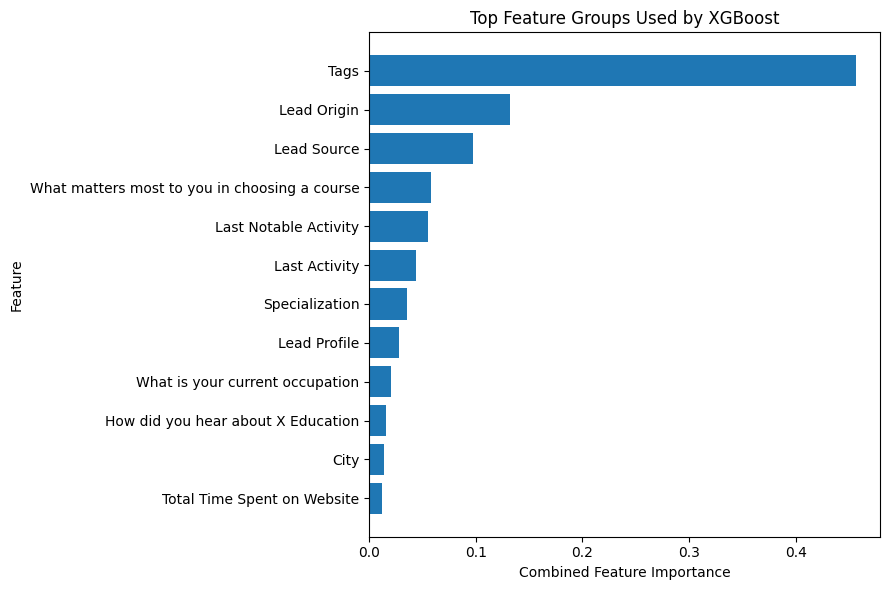

In [90]:
top_groups = grouped_importance.head(12).sort_values()

plt.figure(figsize=(9, 6))

plt.barh(
    top_groups.index,
    top_groups.values
)

plt.title("Top Feature Groups Used by XGBoost")
plt.xlabel("Combined Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [91]:
feature_importance_final.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


In [92]:
overall_conversion = data["Converted"].mean() * 100

high_conversion = priority_performance.loc[
    "High", "conversion_rate"
]

low_conversion = priority_performance.loc[
    "Low", "conversion_rate"
]

print("BUSINESS SUMMARY")
print("=" * 50)

print(f"Total leads analysed: {len(data):,}")
print(f"Overall conversion rate: {overall_conversion:.2f}%")
print(f"High-priority lead conversion rate: {high_conversion:.2f}%")
print(f"Low-priority lead conversion rate: {low_conversion:.2f}%")

print("\nRecommended strategy:")
print("- Prioritize High-score leads first.")
print("- Use Medium-score leads as the second priority.")
print("- Reduce manual effort on Low-score leads.")

BUSINESS SUMMARY
Total leads analysed: 9,240
Overall conversion rate: 38.54%
High-priority lead conversion rate: 94.57%
Low-priority lead conversion rate: 4.70%

Recommended strategy:
- Prioritize High-score leads first.
- Use Medium-score leads as the second priority.
- Reduce manual effort on Low-score leads.


## Conclusion

This project developed an AI-based lead scoring system to help X Education identify and prioritize leads that are more likely to convert.

After cleaning and exploring 9,240 lead records, multiple machine learning models were compared, including Logistic Regression, Random Forest, and XGBoost. XGBoost achieved the best performance on the test data, with 94.05% accuracy and a ROC-AUC of 0.98.

The model's predicted conversion probabilities were converted into a Lead Score from 0 to 100. Leads were then divided into High, Medium, and Low priority groups.

The results showed a clear difference between these groups. High-priority leads had an observed conversion rate of 94.57%, while Low-priority leads had a conversion rate of only 4.70%. This shows that the scoring system can help the sales team focus their time and effort on more promising leads.

Feature analysis was also performed to understand which variables were most useful to the model. Potential data leakage from features such as Tags and Last Activity was investigated by training a separate model without these features. This produced lower performance, highlighting the importance of considering when each feature becomes available in a real sales process.

Overall, the project demonstrates how machine learning can be used to turn historical lead data into actionable sales priorities and support more efficient lead management.

In [93]:
import joblib

joblib.dump(
    final_model,
    "lead_scoring_model.pkl"
)

print("Lead scoring model saved successfully.")

Lead scoring model saved successfully.


In [94]:
import json

# Get the exact feature columns used by the model
feature_columns = X_train.columns.tolist()

# Get categorical values from the training data
category_options = {}

for column in categorical_features:
    category_options[column] = sorted(
        X_train[column].dropna().astype(str).unique().tolist()
    )

# Get default values for numerical features
numeric_defaults = {}

for column in numeric_features:
    numeric_defaults[column] = float(
        X_train[column].median()
    )

# Save model information
model_info = {
    "feature_columns": feature_columns,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "category_options": category_options,
    "numeric_defaults": numeric_defaults
}

with open("model_info.json", "w") as file:
    json.dump(model_info, file, indent=4)

print("Model information saved successfully.")

Model information saved successfully.


In [95]:
# Create a template using the exact training columns

template = X_train.iloc[[0]].copy()

template.to_csv(
    "lead_scoring_input_template.csv",
    index=False
)

print("Input template created successfully.")
print("Columns:", len(template.columns))

Input template created successfully.
Columns: 29


In [96]:
from google.colab import files

files.download("lead_scoring_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [97]:
files.download("model_info.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [98]:
files.download("lead_scoring_input_template.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>